In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from scipy.stats import norm
import os

# Exploratory Data Analysis

In [2]:
# The filepath should be "{filepath}/CRMLSSold...."

filepath = '../data/raw'

## Data Ingestion

We populate the database with our training data, dealing with the inconsistent NaN values and adding a column ReadDate to represent the month the data is sourced from.

In [3]:
training_months = range(6, 13)
conn = duckdb.connect('CRMLS.db')

files = [f for f in os.listdir(filepath) if not f.startswith('.')]

conn.query(f"""
CREATE OR REPLACE TABLE Property AS
SELECT
    * EXCLUDE (filename),
    strptime(
        regexp_extract(filename, 'CRMLSSold(\\d{{6}})\\.csv$', 1),
        '%Y%m'
    )::DATE AS ReadDate
FROM read_csv_auto(
    '{filepath}/CRMLSSold*.csv',
    filename = True,
    nullstr = ['NaN','nan','N/A','NA','', 'NULL']
)
""")



FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/raw'

We follow the instructions to filter out invalid observations. Latitude and Longitude are bounded reasonably within California, which is where the houses are supposed to be located.

In [ ]:
df = conn.query(
    """
    SELECT *
    FROM Property
    WHERE
        PropertyType = 'Residential'
        AND PropertySubType = 'SingleFamilyResidence'
        AND ClosePrice > 0
        AND LivingArea > 0
        AND Latitude IS NOT NULL
        AND Longitude IS NOT NULL
        AND Latitude BETWEEN 32 AND 43
        AND Longitude BETWEEN -125 AND -113
    """
).to_df(date_as_object=True)

df.set_index('ListingId', inplace=True)

df


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,ReadDate
ListingId,,,,,,,,,,,,,,,,,,,,,
EV21134678,TheInlandGateway,TheInlandGateway,None,True,<NA>,<NA>,False,"889,000",523319952,hutton@cbappteam.com,...,"9,600",0,True,2,Rim of the World,92352,0,"9,600",None,2025-06-01
25559373,BeverlyHillsGreaterLa,BeverlyHillsGreaterLa,Wood,True,<NA>,<NA>,False,"1,899,999",1118606385,chase.campen@compass.com,...,"10,400",NaN,False,NaN,None,90046,NaN,"10,400",None,2025-06-01
ML82012939,Mlslistings,Mlslistings,None,False,<NA>,<NA>,<NA>,NaN,1118606192,stanleylo@greenbanker.com,...,"22,505",NaN,False,3,Other,94010,NaN,"22,505",None,2025-06-01
PW25146750,PacificWest,PacificWest,None,True,<NA>,<NA>,False,"865,000",1118604114,matt@majorleaguesocal.com,...,"4,800",3,False,2,Placentia-Yorba Linda Unified,92886,0,"4,800",None,2025-06-01
41103262,BayEast,BayEast,"Carpet,Laminate",<NA>,<NA>,<NA>,False,"875,000",1118603794,brianrowland.homes@gmail.com,...,"5,500",NaN,False,4,None,94546,NaN,"5,500",None,2025-06-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GD23212467,Glendale,Glendale,"Tile,Wood",True,<NA>,<NA>,False,"795,000",1048440089,narbe.avanessian@evrealestate.com,...,"105,281",3,False,3,Antelope Valley Union,93551,0,"105,281",None,2025-12-01
ML81923705,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,<NA>,<NA>,<NA>,"15,950,000",1046617538,hshacham@cbnorcal.com,...,"15,118",NaN,False,2,Palo Alto Unified,94301,NaN,"15,118",None,2025-12-01
NS23056449,NorthSanLuisObispo,NorthSanLuisObispo,"Carpet,Laminate",True,<NA>,<NA>,False,"899,900",1035678879,carolynne@countryrealestate.com,...,20,3,False,0,King City Joint Union,93426,0,"871,200",None,2025-12-01


In [ ]:
df.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,ListingKeyNumeric,TaxAnnualAmount,...,TaxYear,BuildingAreaTotal,BedroomsTotal,BelowGradeFinishedArea,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet
count,"78,687","78,845","78,845","78,845","78,845","78,845","78,845","78,845","78,845",0,...,0,"5,282","78,845",566,"70,833","77,544","48,262","75,698","55,844","77,534"
mean,"1,398,632","1,121,332,541","1,326,619",35,-119,"2,043","1,251,985",40,"1,121,332,541",NaN,...,NaN,"2,490",3,70,1,"16,867",2,2,102,"415,844"
std,"9,491,169","12,653,064","8,431,060",2,2,"1,050","1,587,261",50,"12,653,064",NaN,...,NaN,"1,854",1,315,0,"102,748",1,3,319,"17,647,868"
min,0,"425,795,803",485,33,-124,100,"13,000",-265,"425,795,803",NaN,...,NaN,352,0,0,1,0,0,0,0,0
25%,"639,000","1,113,051,501","625,000",34,-119,"1,384","625,000",9,"1,113,051,501",NaN,...,NaN,"1,491",3,0,1,"5,429",1,2,0,"5,663"
50%,"899,000","1,118,605,232","885,000",34,-118,"1,814","889,900",22,"1,118,605,232",NaN,...,NaN,"2,023",3,0,1,"7,113",3,2,0,"7,294"
75%,"1,425,000","1,130,143,522","1,400,000",35,-117,"2,429","1,399,000",54,"1,130,143,522",NaN,...,NaN,"2,925",4,0,2,"10,000",3,2,126,"10,454"
max,"1,302,000,000","1,150,041,639","989,500,000",42,-114,"56,500","137,500,000",894,"1,150,041,639",NaN,...,NaN,"56,500",19,"3,490",2,"13,072,356",44,500,"15,750","1,938,942,720"


### Key observations

- `ListingKey` is the ID
- Target variable is `ClosePrice`, not `ListPrice` or `OriginalListPrice`
- NaN values are coded inconsistently
- Possibly invalid values in ParkingTotal, DaysOnMarket

### Target Variable Analysis

In [ ]:
pd.options.display.float_format = '{:,.0f}'.format

df['ClosePrice'].describe(include='all')

count        78,845
mean      1,326,619
std       8,431,060
min             485
25%         625,000
50%         885,000
75%       1,400,000
max     989,500,000
Name: ClosePrice, dtype: float64

With our target variable, there are significant deviations and extreme outliers. As per the instructions, however, we will include them in the training data and only remove them in the test set. This distribution will be heavily right-skewed.

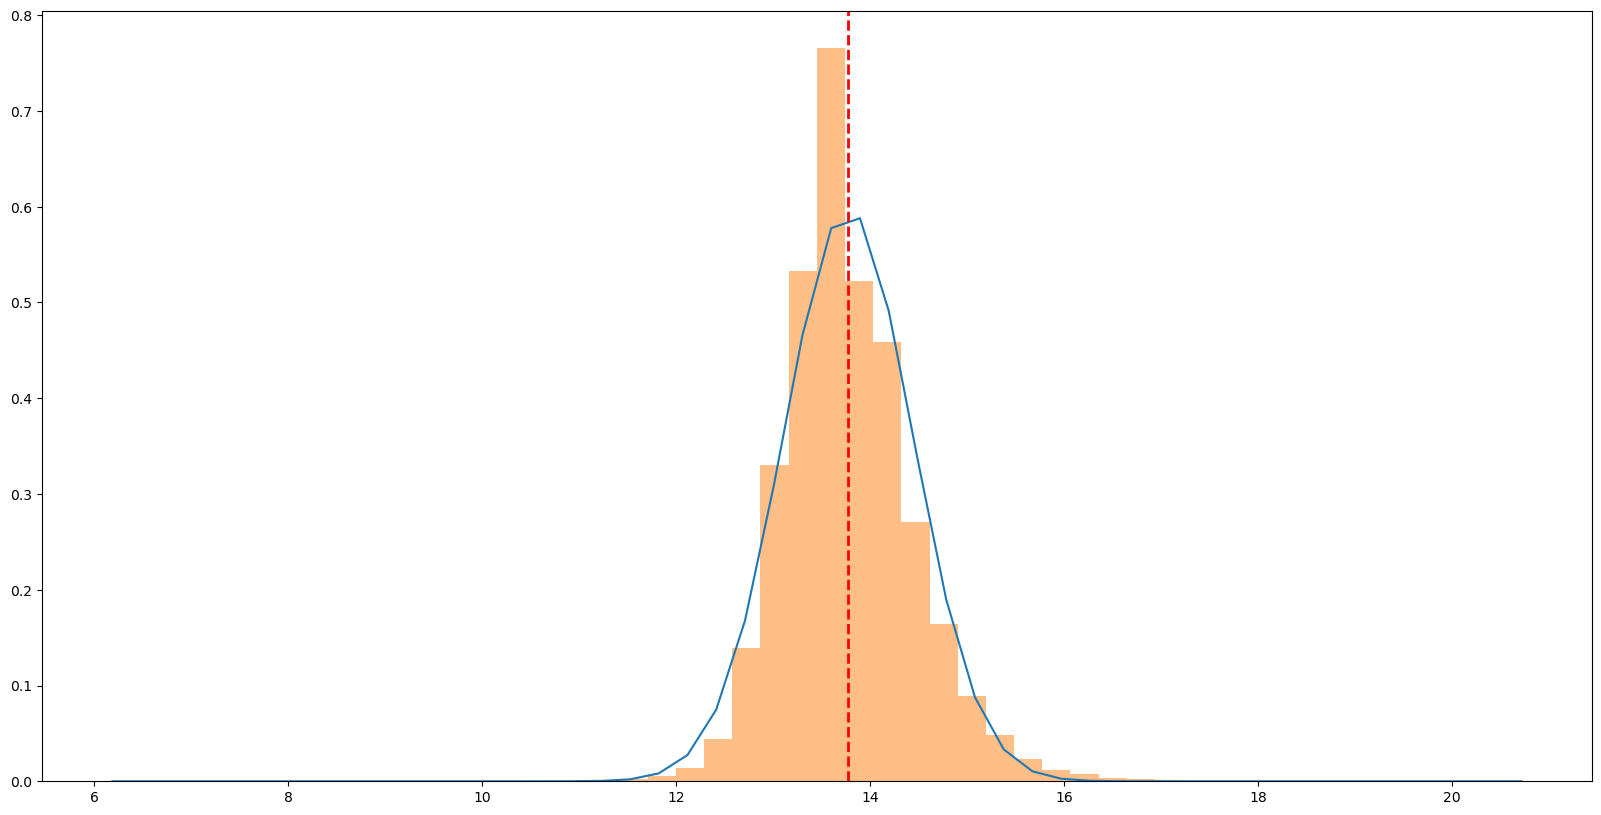

In [ ]:
# Log price
logged_price = np.log(df['ClosePrice'])

fig = plt.figure(figsize = (20,10))
domain = np.linspace(np.min(logged_price), np.max(logged_price))
mu, sigma = np.mean(logged_price), np.std(logged_price, ddof=1)
normal_curve = norm.pdf(domain, mu, sigma)
plt.plot(domain, normal_curve, label='Normal')
plt.hist(logged_price, bins=50, label='Normal', alpha=0.5, density=True)
plt.axvline(x=mu, color='r', linestyle='dashed', linewidth=2)

plt.show()

The log price, however, appears to be normally distributed, which works out better in case the expensive outliers dominate the loss function when we do regression.

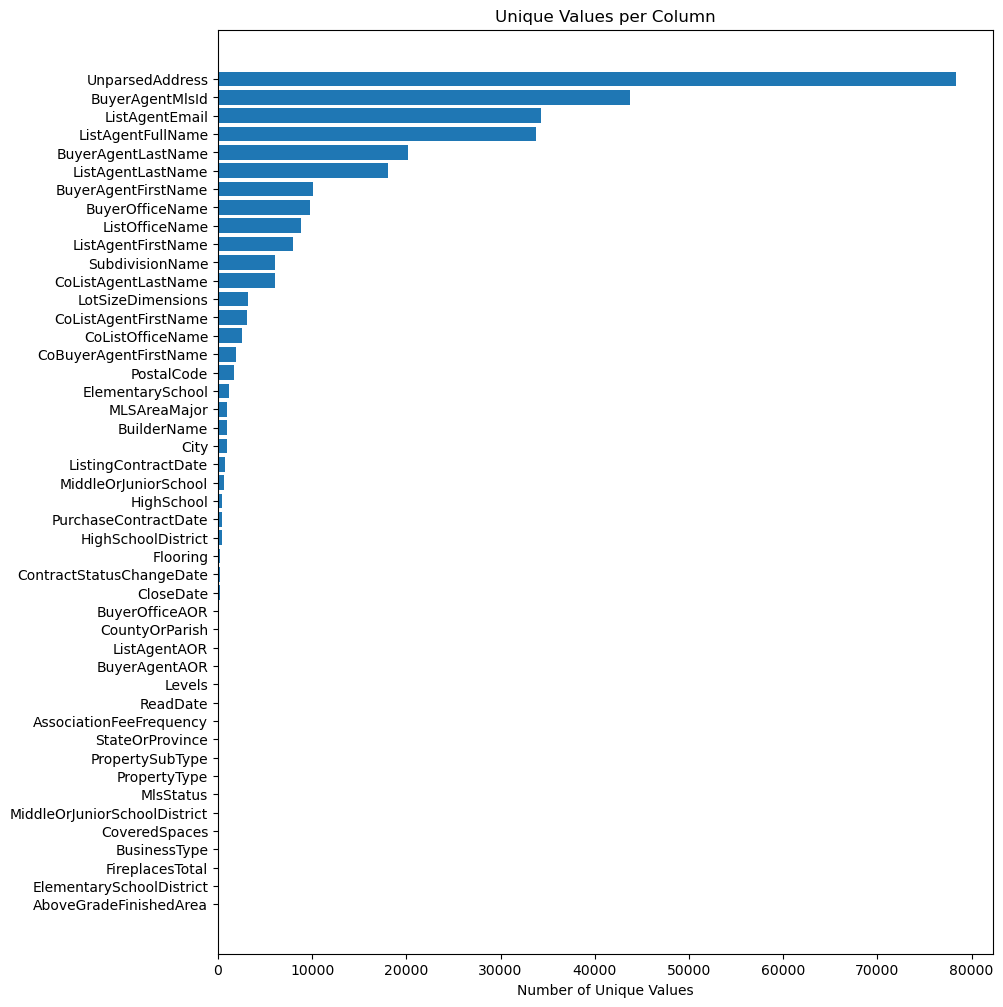

In [ ]:
def column_unique_plot(data: pd.DataFrame):
    categorical_cols = data.select_dtypes(include=["object"]).columns
    unique_counts = data[categorical_cols].nunique()
    unique_counts = unique_counts.sort_values(ascending=True)

    plt.figure(figsize=(10, 12))
    plt.barh(unique_counts.index, unique_counts.values)
    plt.xlabel("Number of Unique Values")
    plt.title("Unique Values per Column")
    plt.show()

column_unique_plot(df)

### Missing Value Identification

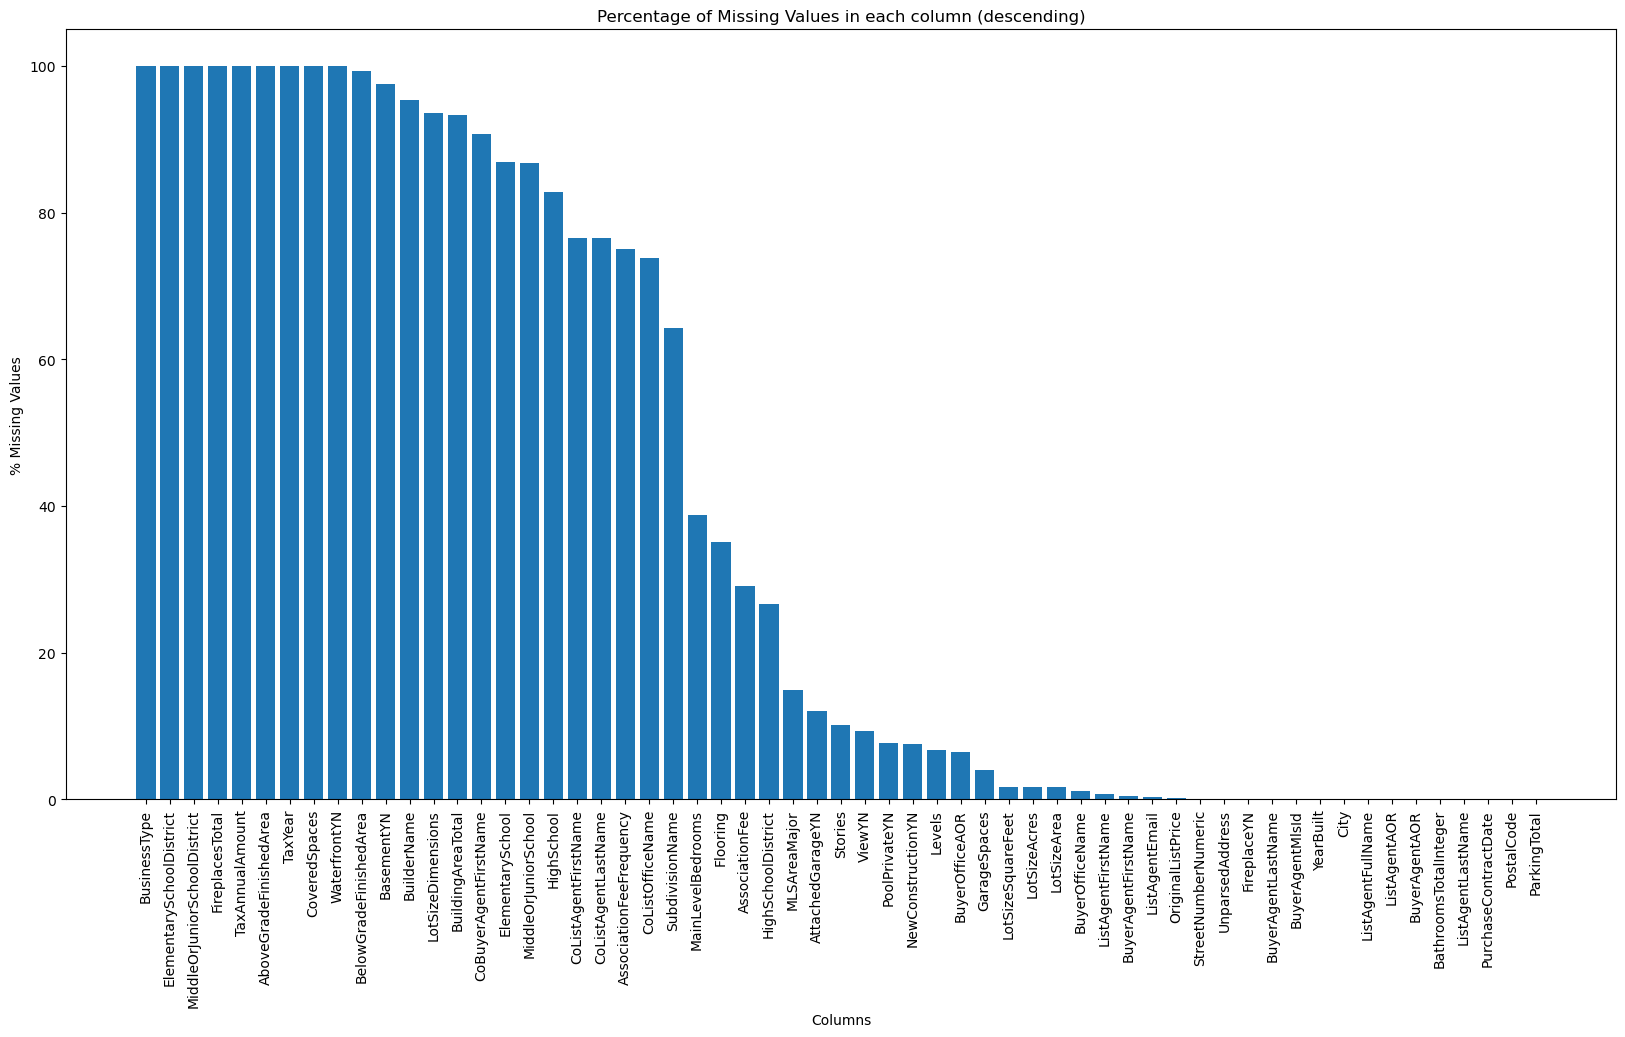

In [ ]:
def column_na_plot(data: pd.DataFrame):
    missing_percentages = data.isna().mean().sort_values(ascending=False) * 100
    missing_percentages = missing_percentages[missing_percentages > 0]

    plt.figure(figsize = (20,10))
    plt.bar(x=missing_percentages.index, height=missing_percentages)
    plt.xticks(rotation=90)
    plt.xlabel('Columns')
    plt.ylabel('% Missing Values')
    plt.title('Percentage of Missing Values in each column (descending)')
    plt.show()

    return missing_percentages

missing_percentages = column_na_plot(df)

Obviously, without data, there would be no way to draw insightful conclusions on anything. For that reason, we would generally want to drop columns with high missingness (say, over 50%).

Missingness causes problems: How can we run models like linear regression if they cannot accept missing values? This dataset is so vast that simply dropping any rows with missing values may leave us with too little workable data. But then how should we impute in each column?

I will do some EDA columns with high missingness, just in case there is some way they could still be useful to our models.

In [ ]:
high_missing_columns = missing_percentages[(missing_percentages > 30) & (missing_percentages < 100)].index
high_missing_columns

Index(['WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'BuilderName',
       'LotSizeDimensions', 'BuildingAreaTotal', 'CoBuyerAgentFirstName',
       'ElementarySchool', 'MiddleOrJuniorSchool', 'HighSchool',
       'CoListAgentFirstName', 'CoListAgentLastName',
       'AssociationFeeFrequency', 'CoListOfficeName', 'SubdivisionName',
       'MainLevelBedrooms', 'Flooring'],
      dtype='object')

### Ideas

I feel comfortable about dropping the "person" "name" columns without further analysis, for practical and ethical reasons.

We can safely impute `BasementYN` and `WaterfrontYN` missing values with False, since they are only present when True.

We could impute other missing data as string "None"?

**Agent/Transaction Fields** (`CoBuyerAgentFirstName`, `CoListAgentLastName`, `CoListOfficeName`)
- **Missing indicates solo agent/office involvement**.
- Could be useful as a binary feature: `HasCoAgent`, `HasCoOffice`.

### We now compare the mean Closing price of when values are missing compared to when they're present.

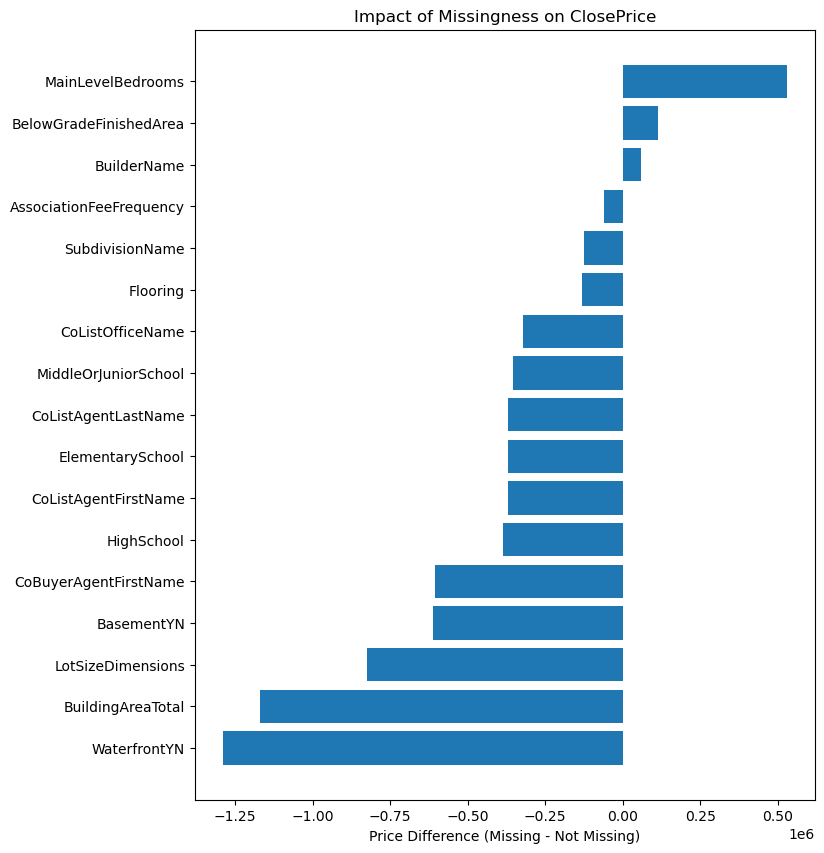

In [ ]:
results = []

for col in high_missing_columns:
    means = df.groupby(df[col].isna())["ClosePrice"].mean()
    
    results.append({
        "Feature": col,
        "Missing": means.get(True, None),
        "Not Missing": means.get(False, None)
    })

missing_df = pd.DataFrame(results)

missing_df["Difference"] = (
    missing_df["Missing"] - missing_df["Not Missing"]
)

missing_df = missing_df.sort_values("Difference")

plt.figure(figsize=(8, 10))
plt.barh(missing_df["Feature"], missing_df["Difference"])
plt.xlabel("Price Difference (Missing - Not Missing)")
plt.title("Impact of Missingness on ClosePrice")
plt.show()


In general, when the data is present, the mean closing price is significantly higher. This makes sense for WaterFrontYN and BasementYN, considering that the existence of either suggests a home with more rooms. However, the others perhaps present a bias where the data was only recorded because the listing itself was more luxurious or high-quality.

Interestingly, the presence of `MainLevelBedrooms` correlates negatively with closing price. This may be because luxury homes generally have bedrooms in upper floors and so there would be no main level bedrooms to even consider. Single-story homes may be more likely to fill in this information.

Missingness here is not random and seems to offer its own predictive influence.

In [ ]:
for column in high_missing_columns:
    if pd.api.types.is_numeric_dtype(df[column]):
        corr = df[[column, "ClosePrice"]].dropna().corr().iloc[0, 1]
        print(f"{column}: {corr}")

WaterfrontYN: nan
BelowGradeFinishedArea: 0.530663027211954
BasementYN: nan
BuildingAreaTotal: 0.651877119087507
MainLevelBedrooms: -0.013792551142458195


On top of missingness of the `BuildingAreaTotal` having an effect on close price, there is also strong positive correlation with respect to the few values (around 10%) that are present. I would consider feature engineering a missingness indicator on top of filling the NA rows with the median building area total.

### Geolocatoinal Analysis

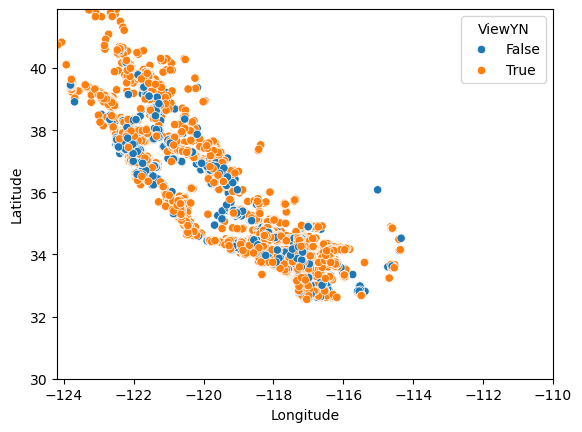

In [ ]:
sns.scatterplot(
    data=df[df['ViewYN'].notnull()],
    x='Longitude',
    y='Latitude',
    hue='ViewYN',
)
plt.xlim(np.min(df['Longitude']), -110)
plt.ylim(30, np.max(df['Latitude']))

plt.show()